# INSTALL LIBRARIES

In [1]:
!pip install selenium beautifulsoup4 pandas lxml openpyxl

# IMPORT LIBRARIES

In [9]:
import time, re, random
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
import matplotlib.pyplot as plt

In [3]:
import requests
from bs4 import BeautifulSoup

url = 'https://www.formula1.com/en/results.html/2023/drivers.html'
headers = {"User-Agent": "Mozilla/5.0"}   

response = requests.get(url, headers=headers, timeout=15)

if response.status_code == 200:
    print("Link ngon")
    soup = BeautifulSoup(response.text, "lxml")
    print(soup.title.get_text(strip=True))
else:
    print(f"Link chớt (status {response.status_code})")

Link ngon
2023 DRIVERS' STANDINGS


# LINK CELLPHONES

In [4]:
TARGET = 1000
BASE = "https://cellphones.com.vn"


CATEGORIES = {
    "mobile":     f"{BASE}/mobile.html",
    "tablet":     f"{BASE}/tablet.html",
    "laptop":     f"{BASE}/laptop.html",
    "am_thanh":   f"{BASE}/thiet-bi-am-thanh.html",
    "phu_kien":   f"{BASE}/phu-kien.html",
    "do_choi_cn": f"{BASE}/do-choi-cong-nghe.html",
}

In [5]:
opts = Options()
opts.add_argument("--headless=new")          # bỏ dòng này nếu muốn xem trình duyệt chạy
opts.add_argument("--window-size=1400,900")
opts.add_argument("--disable-blink-features=AutomationControlled")
opts.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/124.0 Safari/537.36")

driver = webdriver.Chrome(options=opts)      # Selenium 4.6+ tự tải chromedriver
driver.get(CATEGORIES["mobile"])
time.sleep(5)
print(driver.title)

Điện thoại thông minh | Smartphone chính hãng, giá rẻ


In [6]:
candidates = ["div.product-info-container", "div.product-item",
              "div.product-info", "a.product__link"]
for sel in candidates:
    print(sel, "->", len(driver.find_elements(By.CSS_SELECTOR, sel)))

div.product-info-container -> 20
div.product-item -> 20
div.product-info -> 20
a.product__link -> 20


# CHECK DIV BY DIV VA CONTAINERS O BACKEND

In [7]:
CARD_SEL = "div.product-info-container"      
MORE_XPATH = "//a[contains(., 'Xem thêm')] | //button[contains(., 'Xem thêm')]"

def count_cards():
    return len(driver.find_elements(By.CSS_SELECTOR, CARD_SEL))

def load_category(url, max_items, max_stuck=3):
    """Mở danh mục, bấm 'Xem thêm' đến khi đủ max_items hoặc hết sản phẩm."""
    driver.get(url)
    time.sleep(4)
    stuck = 0
    while stuck < max_stuck:
        n = count_cards()
        if n >= max_items:
            break
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1.5)
        btns = driver.find_elements(By.XPATH, MORE_XPATH)
        if btns:
            try:
                driver.execute_script("arguments[0].click();", btns[0])
            except Exception as e:
                print("  Click lỗi:", e)
        time.sleep(random.uniform(2, 3.5))   # nghỉ để lịch sự với server
        n2 = count_cards()
        print(f"  đã load: {n2}")
        stuck = stuck + 1 if n2 == n else 0
    return driver.page_source

def txt(node):
    return node.get_text(strip=True) if node else None

def full_url(u):
    if not u: return None
    return u if u.startswith("http") else BASE + u

def parse_html(html, category):
    soup = BeautifulSoup(html, "lxml")
    out = []
    for c in soup.select(CARD_SEL):
        a = c.select_one("a")
        out.append({
            "category": category,
            "name": txt(c.select_one(".product__name")),
            "price_sale": txt(c.select_one(".product__price--show")),
            "price_original": txt(c.select_one(".product__price--through")),
            "discount": txt(c.select_one(".product__price--percent-detail")),
            "url": full_url(a["href"]) if a and a.has_attr("href") else None,
        })
    return out

In [ ]:
all_rows, seen = [], set()

for cat, url in CATEGORIES.items():
    if len(seen) >= TARGET:
        break
    need = TARGET - len(seen)
    print(f"\n[{cat}] {url} | còn thiếu {need}")

    html = load_category(url, max_items=need + 150)   # dư một ít vì có thể trùng
    rows = parse_html(html, cat)

    if not rows:
        print("  ⚠ 0 thẻ sản phẩm: kiểm tra lại link hoặc CARD_SEL")
        continue

    new = 0
    for r in rows:
        if r["url"] and r["url"] not in seen:
            seen.add(r["url"])
            all_rows.append(r)
            new += 1
    print(f"  -> thêm {new} dòng mới | tổng url duy nhất: {len(seen)}")

df_raw = pd.DataFrame(all_rows)
print("\nRaw:", df_raw.shape)
df_raw["category"].value_counts()


[mobile] https://cellphones.com.vn/mobile.html | còn thiếu 1000
  đã load: 40
  đã load: 60
  đã load: 80
  đã load: 100
  đã load: 120
  đã load: 140
  đã load: 160
  đã load: 180
  đã load: 200
  đã load: 220
  đã load: 240
  đã load: 240


# RELOAD DATA

In [ ]:
df_raw.to_csv("cellphones_raw.csv", index=False, encoding="utf-8-sig")
df_raw.tail()

In [ ]:
df = pd.read_csv("cellphones_raw.csv")

def to_int(s):
    if pd.isna(s): return None
    d = re.sub(r"\D", "", str(s))
    return int(d) if d else None

# Ghi nhận "Giá Liên Hệ" trước khi chuyển sang số
df["is_contact"] = df["price_sale"].astype(str).str.contains("Liên", case=False, na=False)

for col in ["price_sale", "price_original", "discount"]:
    df[col] = df[col].apply(to_int)

df = (df.dropna(subset=["name", "url"])
        .drop_duplicates(subset="url")
        .reset_index(drop=True))

print(df.shape)
df.info()

In [ ]:
print("Đủ mục tiêu:", len(df) >= TARGET)
print(df["category"].value_counts())
print(df.isna().sum())

df.to_csv("cellphones_clean.csv", index=False, encoding="utf-8-sig")
df.to_excel("cellphones_clean.xlsx", index=False)

# DATA VISUALIZATION

In [10]:
df = pd.read_csv("cellphones_clean.csv")

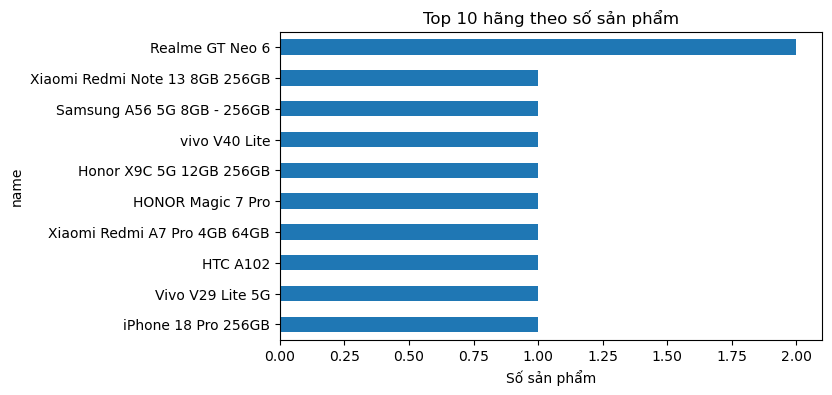

In [11]:
df["name"].value_counts().head(10).sort_values().plot(kind="barh", figsize=(7, 4))
plt.title("Top 10 hãng theo số sản phẩm")
plt.xlabel("Số sản phẩm")
plt.show()

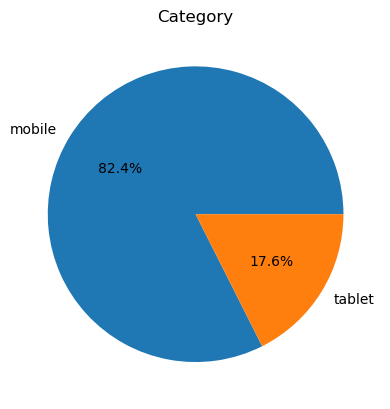

In [12]:
df["category"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Category")
plt.ylabel("")
plt.show()

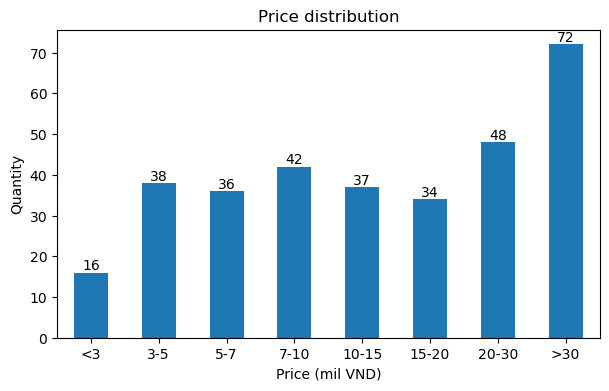

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

price = df["price_original"] / 1e6          

bins = [0, 3, 5, 7, 10, 15, 20, 30, float("inf")]
labels = ["<3", "3-5", "5-7", "7-10", "10-15", "15-20", "20-30", ">30"]

counts = pd.cut(price, bins=bins, labels=labels).value_counts().sort_index()

ax = counts.plot(kind="bar", figsize=(7, 4))
ax.bar_label(ax.containers[0])                 
plt.title("Price distribution")
plt.xlabel("Price (mil VND)")
plt.ylabel("Quantity")
plt.xticks(rotation=0)
plt.show()